In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import re

data_path = Path("../data")
transactions_path = data_path / "transactions.csv"
transactions = pd.read_csv(transactions_path)
transactions.shape

(80800, 6)

данные - 80800 строк и 6 колонок

In [2]:
def parse_date(value):
    s = str(value).strip()
    if re.fullmatch(r"\d{4}-\d{2}-\d{2}", s):
        return pd.to_datetime(s, format="%Y-%m-%d", errors="coerce")
    if re.fullmatch(r"\d{4}/\d{2}/\d{2}", s):
        return pd.to_datetime(s, format="%Y/%m/%d", errors="coerce")
    if re.fullmatch(r"\d{2}/\d{2}/\d{4}", s):
        return pd.to_datetime(s, format="%d/%m/%Y", errors="coerce")
    if re.fullmatch(r"\d{2}\.\d{2}\.\d{4}", s):
        return pd.to_datetime(s, format="%d.%m.%Y", errors="coerce")

transactions["date"] = transactions["date"].apply(parse_date)
transactions["date"].min(), transactions["date"].max()

(Timestamp('2024-01-01 00:00:00'), Timestamp('2026-04-30 00:00:00'))

период транзакций - с 1 янв 2024 по 30 апереля 2026 

In [3]:
unique_counterparties = pd.concat([transactions["sender_id"], transactions["receiver_id"]]).nunique()
unique_counterparties

7215

7215 уникальных контрагентов

In [4]:
top_outgoing = transactions.groupby("sender_id")["amount_kzt"].sum().sort_values(ascending=False).head(20)
top_outgoing

sender_id
720221554469    7.554451e+08
580811600403    7.445998e+08
310909691346    7.187724e+08
170915651329    7.069924e+08
181226594058    7.033694e+08
140512557513    6.866489e+08
401110643824    6.791805e+08
570328465547    6.405617e+08
941101594315    6.364129e+08
460614400792    6.136171e+08
970913552723    6.118457e+08
270122476708    6.116453e+08
371002684702    5.981690e+08
750125644155    5.935096e+08
861218496740    5.875824e+08
100925580902    5.873830e+08
450815601992    5.725905e+08
181120401530    5.718899e+08
280812467978    5.665917e+08
641104654277    5.482331e+08
Name: amount_kzt, dtype: float64

In [5]:
top_incoming = transactions.groupby("receiver_id")["amount_kzt"].sum().sort_values(ascending=False).head(20)
top_incoming

receiver_id
850603506938    3.733961e+08
711020691210    3.494212e+08
551211641020    3.460529e+08
410517502025    3.351119e+08
730424495604    3.230030e+08
121125400846    3.086955e+08
850623490114    3.056108e+08
731211426100    2.842297e+08
990508519961    2.741360e+08
861228440096    2.610135e+08
791108595547    2.609540e+08
740201661314    2.581422e+08
870618658764    2.558455e+08
721125608037    2.556351e+08
460112529539    2.548255e+08
080421521108    2.544740e+08
900326509443    2.526926e+08
670603689146    2.499834e+08
630511555336    2.461624e+08
480218577728    2.454711e+08
Name: amount_kzt, dtype: float64

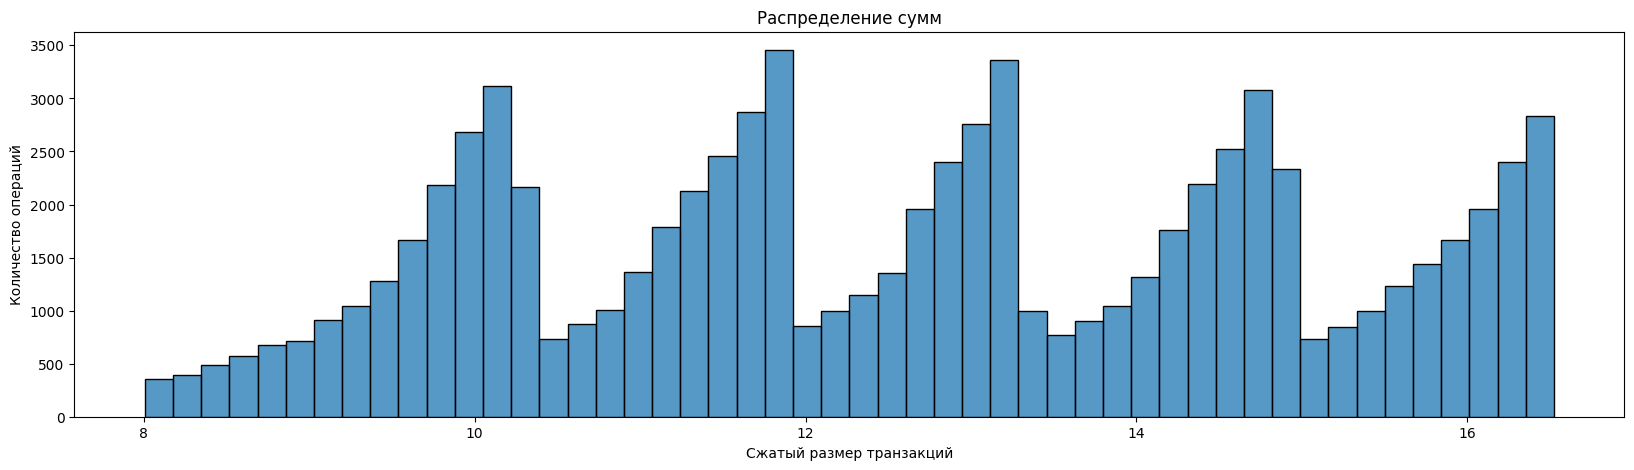

In [6]:
plt.figure(figsize=(20, 5))
sns.histplot(np.log1p(transactions["amount_kzt"].abs()), bins=50)
plt.title("Распределение сумм")
plt.xlabel("Сжатый размер транзакций")
plt.ylabel("Количество операций")
plt.show()

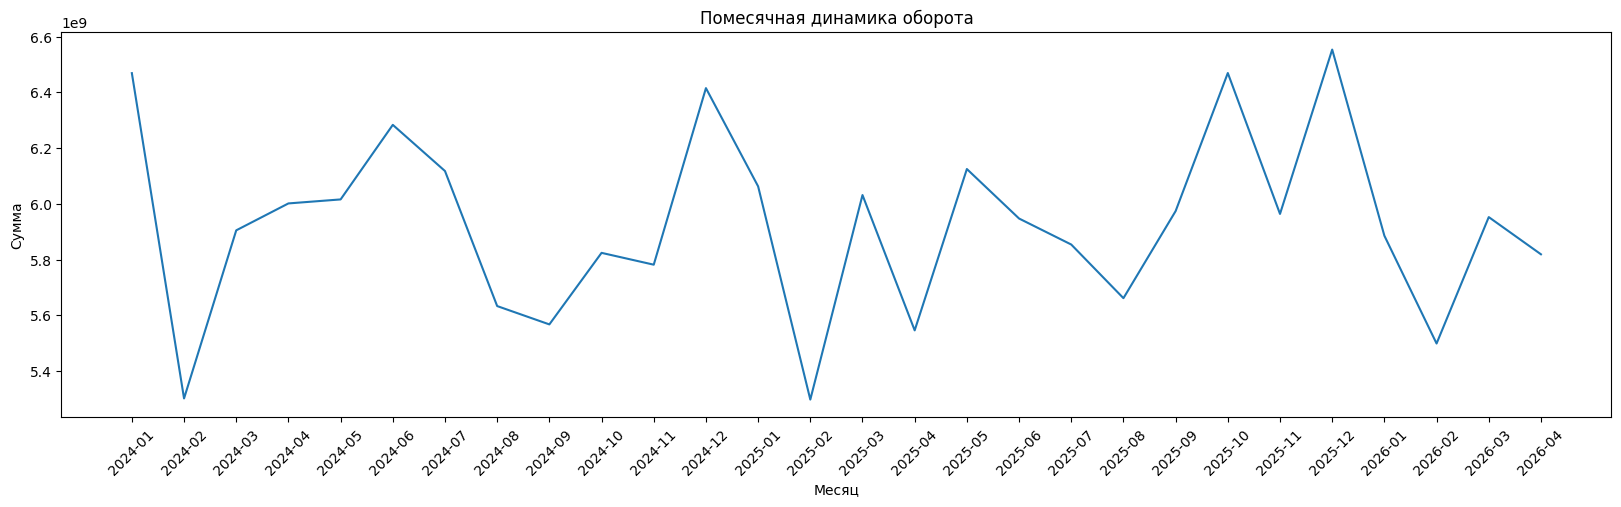

In [7]:
monthly_turnover = transactions.groupby(transactions["date"].dt.to_period("M"))["amount_kzt"].sum().reset_index()
monthly_turnover["date"] = monthly_turnover["date"].astype(str)
plt.figure(figsize=(20, 5))
sns.lineplot(data=monthly_turnover, x="date", y="amount_kzt")
plt.xticks(rotation=45)
plt.ylabel("Сумма")
plt.xlabel("Meсяц")
plt.title("Помесячная динамика оборота")
plt.show()

аномалия 1: резкое снижение оборота в некоторые месяца (февраль 2024 и 2025), значительно отличается от остальных месяцев (возможно, сезонность)

In [8]:
transactions.sort_values("amount_kzt", key=lambda x: x.abs(),ascending=False).head(10)

,sender_id,receiver_id,date,amount_kzt,description,doc_type
19464,351225697268,771226432263,2024-08-16,14998616.42,"Разработка ПО по ТЗ от 12.03.2025, договор №51",ACT
50578,170819560994,450922466074,2026-01-21,14998564.39,"Топливо ДТ-Л-К5, 3 тонны",WAYBILL
59157,900905507454,210707151485,2024-10-29,14997314.23,"Аренда помещения по адресу пр. Достык 91, дого...",INVOICE
63414,100925580902,970601519214,2024-12-14,14996892.55,Тепловая энергия за период 01-28.02.2025,WAYBILL
15332,010428684891,160902692016,2025-02-16,14995761.22,Медицинские маски — 5000 шт,INVOICE
39607,430521545361,071116627700,2025-08-02,14995136.52,"Правовое сопровождение сделки M&A, договор №49",WAYBILL
65908,000110589200,400705533401,2024-09-23,14994647.23,Рекламные услуги в Instagram за март,INVOICE
8762,911021603883,450917538197,2025-08-22,14992336.36,Транспортные услуги по договору №14,ACT
19526,401109525007,910919589467,2025-03-13,14988384.41,"Доставка груза 5 тонн, маршрут Шымкент-Тараз",INVOICE
10467,530711676331,850803502893,2024-03-22,14988040.10,Консультационные услуги по ВЭД,ACT


аномалия 2: неправдободобные переводы (15 млн. за рекламу в месяц или на 5000 шт медицинский масок - подозрительная активность)

In [9]:
print(transactions.duplicated().sum())
print((transactions["amount_kzt"] < 0).sum())

800
384


аномалия 3: 800 дубликатов. Возможно, повторные переводы, либо же ошибочные дубликаты. + 384 отрицательных переводов, что либо ошибка, либо возврат.

In [10]:
def is_valid(iin):
    s = str(iin).strip()
    if not re.fullmatch(r"\d{12}", s):
        return False
    digits = list(map(int, s))
    b1 = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]
    control = sum(d * w for d, w in zip(digits[:11], b1)) % 11
    if control == 10:
        b2 = [3, 4, 5, 6, 7, 8, 9, 10, 11, 1, 2]
        control = sum(d * w for d, w in zip(digits[:11], b2)) % 11
    if control == 10:
        return False
    return control == digits[11]
transactions["sender_valid"] = transactions["sender_id"].apply(is_valid)
transactions["receiver_valid"] = transactions["receiver_id"].apply(is_valid)
(transactions["sender_valid"] == True).sum(), (transactions["receiver_valid"] == True).sum()

(np.int64(79610), np.int64(79674))

77704 валидных ИИН/БИН

In [11]:
before = {
    "rows": len(transactions),
    "sender_valid": transactions["sender_valid"].mean() * 100,
    "receiver_valid": transactions["receiver_valid"].mean() * 100,
    "empty_description": transactions["description"].isna().mean() * 100,
    "duplicates": transactions.duplicated().sum()
}

transactions["date"] = pd.to_datetime(transactions["date"], errors="coerce")
transactions["date"] = transactions["date"].dt.strftime("%Y-%m-%d")
transactions["description"] = transactions["description"].fillna("")
transactions = transactions.drop_duplicates()
transactions = transactions[transactions["sender_id"].apply(is_valid) & transactions["receiver_id"].apply(is_valid)].copy()

after = {
    "rows": len(transactions),
    "sender_valid": transactions["sender_id"].apply(is_valid).mean() * 100,
    "receiver_valid": transactions["receiver_id"].apply(is_valid).mean() * 100,
    "empty_description": transactions["description"].isna().mean() * 100,
    "duplicates": transactions.duplicated().sum()
}

pd.DataFrame([before, after], index=["Было", "Стало"])

,rows,sender_valid,receiver_valid,empty_description,duplicates
Было,80800,98.527228,98.606436,1.048267,800
Стало,77704,100.000000,100.000000,0.000000,0


Дубликатами считается абсолютно идентичные строки, в том числе и date. После очистки осталось 77704 строк из 80800 изначальных.

In [12]:
transactions[["sender_id", "receiver_id", "date", "amount_kzt", "description", "doc_type"]].to_csv(data_path / "transactions_clean.csv", index=False)